# TP4 Fonctions prédictives 

Membres de l'équipe : 
- Titouan CHOALER chot4078
- Ethan BROUILLET broe5997

## 1. Implémentation de fonctions

### a)

In [8]:
import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier

def model_score(X, y, class_model=KNeighborsClassifier, params={}):
    model = class_model(**params)
    scores = cross_val_score(model, X, y, cv=5)
    return np.mean(scores)

### b)

In [9]:
def bruteforce_optimisation(class_model, grille_param, X, y): 
    max_score = 0
    max_params = {}
    for param in grille_param['n_neighbors']:
        for param2 in grille_param['p']:
            score = model_score(X, y, class_model, {'n_neighbors': param, 'p': param2})
            if score > max_score:
                max_score = score
                max_params = {'n_neighbors': param, 'p': param2}
    return max_params

### c)

In [10]:
import random
import itertools

def randomize_optimisation(class_model, grille_param, X, y, sample_percent):
    combo = list(itertools.product(grille_param['n_neighbors'], grille_param['p']))
    nb_iter = int(len(combo) * (sample_percent / 100))
    randomized_combo = random.sample(combo, nb_iter)
    max_score = 0
    max_params = {}
    for param , param2 in randomized_combo:
        score = model_score(X, y, class_model, {'n_neighbors': param, 'p': param2})
        if score > max_score:
            max_score = score
            max_params = {'n_neighbors': param, 'p': param2}
    return max_params

### d)

In [11]:
def halving_optimisation(class_model, grille_param, X, y, n_splitting):
    combo = list(itertools.product(grille_param['n_neighbors'], grille_param['p']))
    nb_combos = len(combo)
    nb_data = len(X)
    for i in range(1, n_splitting + 1):
        nb_keep = int(nb_data * (i / n_splitting))
        X_keep = X[:nb_keep]
        y_keep = y[:nb_keep]
        score_keep = []
        for param , param2 in combo:
            score = model_score(X_keep, y_keep, class_model, {'n_neighbors': param, 'p': param2})
            score_keep.append((score, (param, param2)))
        score_keep.sort(key=lambda x: x[0], reverse=True)
        nb_score_keep = int(nb_combos * (n_splitting - i) / n_splitting)
        if nb_score_keep == 0 :
            nb_score_keep = 1
        combo = [item[1] for item in score_keep[:nb_score_keep]]
    best_params = {'n_neighbors': combo[0][0], 'p': combo[0][1]}
    return best_params

### e)

In [12]:
from sklearn.gaussian_process import GaussianProcessRegressor
from scipy.stats import norm

def bayesian_optimisation(class_model, grille_param, X, y, s_size, n_iter):
    combo = list(itertools.product(grille_param['n_neighbors'], grille_param['p']))
    E = random.sample(combo, s_size)
    E_score = []
    for param , param2 in E:
        score = model_score(X, y, class_model, {'n_neighbors': param, 'p': param2})
        E_score.append(score)
    gpr = GaussianProcessRegressor()
    gpr.fit(E, E_score)
    for i in range(n_iter):
        mean, std = gpr.predict(combo, return_std=True)
        max_pred_mean = np.max(mean)
        sampled = random.sample(combo, s_size)
        mean_sampled, std_sampled = gpr.predict(sampled, return_std=True)
        proba = norm.cdf((mean_sampled - max_pred_mean) / (std_sampled + 10**-6))
        max_param = sampled[np.argmax(proba)]
        score = model_score(X, y, class_model, {'n_neighbors': max_param[0], 'p': max_param[1]})
        E.append(max_param)
        E_score.append(score)
        gpr.fit(E, E_score)
    best_param = E[np.argmax(E_score)]
    return {'n_neighbors': best_param[0], 'p': best_param[1]}

## 2. Comparaison de fonctions

### a)

In [19]:
import pandas as pd
from sklearn.model_selection import train_test_split

X = pd.read_csv('TP4-data.csv')
y = X['Classe']
X = X.drop(columns=['Classe'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### b)

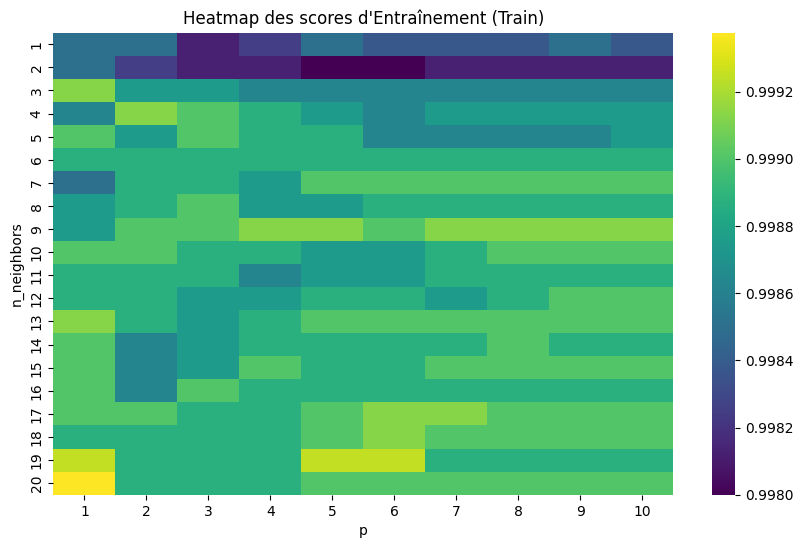

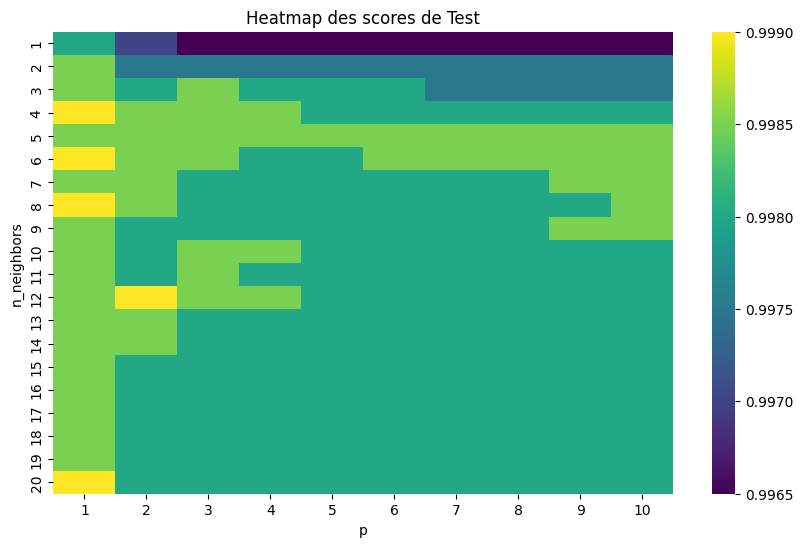

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

n_neighbors_list = [i for i in range(1, 21)]
p_list = [i for i in range(1, 11)]

results = []

for n_neighbors in n_neighbors_list:
    for p in p_list:
        score_train = model_score(X_train, y_train, KNeighborsClassifier, {'n_neighbors': n_neighbors, 'p': p})
        modele = KNeighborsClassifier(n_neighbors=n_neighbors, p=p)
        modele.fit(X_train, y_train)
        score_test = modele.score(X_test, y_test)
        results.append({
            'n_neighbors': n_neighbors,
            'p': p,
            'score_train': score_train,
            'score_test': score_test
        })

df_resultats = pd.DataFrame(results) 
grille_train = df_resultats.pivot(index='n_neighbors', columns='p', values='score_train')
grille_test = df_resultats.pivot(index='n_neighbors', columns='p', values='score_test')

plt.figure(figsize=(10, 6))
sns.heatmap(grille_train, cmap='viridis', annot=False) 
plt.title("Heatmap des scores d'Entraînement (Train)")
plt.show()

plt.figure(figsize=(10, 6))
sns.heatmap(grille_test, cmap='viridis', annot=False)
plt.title("Heatmap des scores de Test")
plt.show()

### c)

In [37]:
from sklearn import model_selection
from sklearn.experimental import enable_halving_search_cv
from skopt import gp_minimize
from skopt.space import Integer
from skopt.utils import use_named_args

best_params1 = bruteforce_optimisation(KNeighborsClassifier, {'n_neighbors': n_neighbors_list, 'p': p_list}, X_train, y_train)
print(" Brute force : ", best_params1)
best_params2 = randomize_optimisation(KNeighborsClassifier, {'n_neighbors': n_neighbors_list, 'p': p_list}, X_train, y_train, 30)
print(" Randomized : ", best_params2)
best_params3 = halving_optimisation(KNeighborsClassifier, {'n_neighbors': n_neighbors_list, 'p': p_list}, X_train, y_train, 5)
print(" Halving : ", best_params3)
best_params4 = bayesian_optimisation(KNeighborsClassifier, {'n_neighbors': n_neighbors_list, 'p': p_list}, X_train, y_train, 5, 100)
print(" Bayesian : ", best_params4)

print("================================================")

best_params_acc1 = model_selection.GridSearchCV(KNeighborsClassifier(), {'n_neighbors': n_neighbors_list, 'p': p_list}, scoring='accuracy')
best_params_acc1.fit(X_train, y_train)
print(" Grid search : ", best_params_acc1.best_params_)
best_params_acc2 = model_selection.RandomizedSearchCV(KNeighborsClassifier(), {'n_neighbors': n_neighbors_list, 'p': p_list}, n_iter=60, scoring='accuracy')
best_params_acc2.fit(X_train, y_train)
print(" Randomized search : ", best_params_acc2.best_params_)
best_params_acc3 = model_selection.HalvingGridSearchCV(KNeighborsClassifier(), {'n_neighbors': n_neighbors_list, 'p': p_list}, factor=5, scoring='accuracy')
best_params_acc3.fit(X_train, y_train)
print(" Halving search : ", best_params_acc3.best_params_)

domain = [Integer(1, 20, name='n_neighbors'), Integer(1, 10, name='p')]

@use_named_args(domain)
def one_minus_score(**params):
    score = model_score(X_train, y_train, KNeighborsClassifier, params)
    return 1 - score

results = gp_minimize(one_minus_score, domain)
best_params_acc4 = {'n_neighbors': results.x[0], 'p': results.x[1]}
print(" Bayesian search : ", best_params_acc4)

 Brute force :  {'n_neighbors': 20, 'p': 1}
 Randomized :  {'n_neighbors': 20, 'p': 1}
 Halving :  {'n_neighbors': 20, 'p': 1}
 Bayesian :  {'n_neighbors': 4, 'p': 2}
 Grid search :  {'n_neighbors': 20, 'p': 1}
 Randomized search :  {'p': 1, 'n_neighbors': 19}
 Halving search :  {'n_neighbors': 9, 'p': 1}


/opt/anaconda3/lib/python3.13/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(20), np.int64(1)] before, using random point [np.int64(20), np.int64(8)]
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(20), np.int64(1)] before, using random point [np.int64(15), np.int64(4)]
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(17), np.int64(6)] before, using random point [np.int64(12), np.int64(3)]
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(20), np.int64(1)] before, using random point [np.int64(17), np.int64(8)]
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/skopt/optimizer/optimize

 Bayesian search :  {'n_neighbors': np.int64(20), 'p': np.int64(1)}


Lorsque l'on execute les huit fonctions pour trouver les meilleurs hyperparamètres  sur le modèle KNeighborsClassifier on obtient :

- les méthodes de recherche exhaustive (bruteforce_optimisation et model_selection.GridSearchCV) ont toutes les deux convergé vers n_neighbors = 20 et p = 1. Ces deux algorithmes testent l'intégralité des 200 combinaisons possibles de la grille. Qu'on obtienne exactement le même résultat valide l'exactitude de notre implémentation par rapport à celle de scikit-learn. Le paramétrage (20, 1) représente l'optimum global absolu sur nos données d'entraînement. On va comparer avec ce que les autres méthodes obtiennent parce que ces deux méthodes sont gourmandes opéarations computationnelles.

- les méthodes d'échantillonnage aléatoire (randomize_optimisation et model_selection.RandomizedSearchCV). On obtient n_neighbors = 20, p = 1 avec le premier et n_neighbors = 19, p = 1 avec le deuxième. Ces algorithmes n'explorent qu'une partie de l'espace de recherche (60 combinaisons sur 200) et ce de façon aléatoire, ce qui fait que si on relance l'execution les resultats change. La version de scikit-learn n'a très probablement pas tiré la combinaison (20, 1) lors de ses 60 itérations, et s'est arrêtée sur (19, 1). Mathématiquement. Avec ces algorithmes on réduit le nombre de calculs mais avec si peux de combinaisons on a de forte chance de ne pas tomber sur les bons resultats.

- les méthodes d'élimination successive (halving_optimisation et model_selection.HalvingGridSearchCV). Pour halving_optimisation (avec s_splitting = 5) on a n_neighbors = 20, p = 1, alors qu'avec model_selection.HalvingGridSearchCV (avec factor = 5) on obtient n_neighbors = 9, p = 1. Le résultat (9, 1) obtenu par scikit-learn montre un problème qui fait que sur les tous premiers sous-échantillons avec peu de données, la configuration k=9 a du obtenir un score temporairement supérieur à k=20. L'optimum global a donc été éliminé prématurément avant de pouvoir être testé sur 100% des données.

- l'optimisation Bayésienne (bayesian_optimisation skopt.gp_minimize). On obtient comme meilleur param n_neighbors = 4, p = 2 pour notre version et avec skopt.gp_minimize on a n_neighbors = 20, p = 1 comme optimum global. Notre implémentation a probablement tiré des échantillons initiaux très performants dans la région de k=4 et p=2, et a privilégié "l'exploitation" de cette zone (qui offre un score local excellent) au détriment de "l'exploration" vers des valeurs de k plus élevées. La version skopt, plus robuste, a réussi à contourner ce minimum local pour retrouver la  solution globale.

Donc pour la distance (p), la forte récurrence de p = 1 laisse supposer que la distance de Manhattan sépare beaucoup plus efficacement les 20 classes de ce jeu de données que la distance Euclidienne. Pour le voisinage (k), les optimums convergent vers une valeur élevée (k = 19 ou 20), ce qui indique qu'il faudra un voisinage large pour lisser le bruit et construire des zones de classification robustes.

### d)

In [52]:
import time
import warnings
from tqdm.notebook import tqdm

X_y = []
X_train_90, X_test_90, y_train_90, y_test_90 = train_test_split(X, y, test_size=0.1, random_state=42, stratify=y)
X_y.append((X_train_90, y_train_90, X_test_90, y_test_90))
X_train_80, X_test_80, y_train_80, y_test_80 = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_y.append((X_train_80, y_train_80, X_test_80, y_test_80))
X_train_70, X_test_70, y_train_70, y_test_70 = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_y.append((X_train_70, y_train_70, X_test_70, y_test_70))
X_train_60, X_test_60, y_train_60, y_test_60 = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)
X_y.append((X_train_60, y_train_60, X_test_60, y_test_60))
X_train_50, X_test_50, y_train_50, y_test_50 = train_test_split(X, y, test_size=0.5, random_state=42, stratify=y)
X_y.append((X_train_50, y_train_50, X_test_50, y_test_50))

sample_percent_list = [10, 30, 50, 80]
s_splitting_list = [2, 5, 10, 20]
s_size_list = [2 , 5, 10, 20]
n_iter_list = [30, 60, 80, 100, 150]
factor_list = [2, 5, 10, 20]

time_bruteforce_list = []
time_randomized_list = []
time_halving_list = []
time_bayesian_list_n_iter = []
time_bayesian_list_s_size = []
time_grid_list = []
time_randomizedS_list = []
time_halvingS_list = []
time_gp_list = []

best_params_bruteforce_list = []
best_params_randomized_list = []
best_params_halving_list = []
best_params_bayesian_list_n_iter = []
best_params_bayesian_list_s_size = []
best_params_grid_list = []
best_params_randomizedS_list = []
best_params_halvingS_list = []
best_params_gp_list = []


for X_train, y_train, X_test, y_test in tqdm(X_y, desc="Progression des Résultats"):
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    start_time = time.time()
    best_params = bruteforce_optimisation(KNeighborsClassifier, {'n_neighbors': n_neighbors_list, 'p': p_list}, X_train, y_train)
    end_time = time.time()
    time_bruteforce_list.append(end_time - start_time)
    best_params_bruteforce_list.append(best_params)

    start_time = time.time()
    best_params = model_selection.GridSearchCV(KNeighborsClassifier(), {'n_neighbors': n_neighbors_list, 'p': p_list}, scoring='accuracy').fit(X_train, y_train).best_params_
    end_time = time.time()
    time_grid_list.append(end_time - start_time)
    best_params_grid_list.append(best_params)

    @use_named_args(domain)
    def gp_function(**params):
        score = model_score(X_train, y_train, KNeighborsClassifier, params)
        return 1 - score

    start_time = time.time()
    with warnings.catch_warnings(): # juste pour enlever les warnings et avoir un output propre
        warnings.simplefilter("ignore")
        results = gp_minimize(gp_function, domain)
    end_time = time.time()
    best_params = {'n_neighbors': results.x[0], 'p': results.x[1]}
    time_gp_list.append(end_time - start_time)
    best_params_gp_list.append(best_params)

    for sample_percent in tqdm(sample_percent_list, desc="Boucle sur sample_percent", leave=False):
        start_time = time.time()
        best_params = randomize_optimisation(KNeighborsClassifier, {'n_neighbors': n_neighbors_list, 'p': p_list}, X_train, y_train, sample_percent)
        end_time = time.time()
        time_randomized_list.append(end_time - start_time)
        best_params_randomized_list.append((best_params, sample_percent))
    
    for s_splitting in tqdm(s_splitting_list, desc="Boucle sur s_splitting", leave=False):
        start_time = time.time()
        best_params = halving_optimisation(KNeighborsClassifier, {'n_neighbors': n_neighbors_list, 'p': p_list}, X_train, y_train, s_splitting)
        end_time = time.time()
        time_halving_list.append(end_time - start_time)
        best_params_halving_list.append((best_params, s_splitting))

    for factor in tqdm(factor_list, desc="Boucle sur factor", leave=False):
        start_time = time.time()
        best_params = model_selection.HalvingGridSearchCV(KNeighborsClassifier(), {'n_neighbors': n_neighbors_list, 'p': p_list}, factor=factor, scoring='accuracy').fit(X_train, y_train).best_params_
        end_time = time.time()
        time_halvingS_list.append(end_time - start_time)
        best_params_halvingS_list.append((best_params, factor))

    for n_iter in tqdm(n_iter_list, desc="Boucle sur n_iter", leave=False):
        start_time = time.time()
        best_params = model_selection.RandomizedSearchCV(KNeighborsClassifier(), {'n_neighbors': n_neighbors_list, 'p': p_list}, n_iter=n_iter, scoring='accuracy').fit(X_train, y_train).best_params_
        end_time = time.time()
        time_randomizedS_list.append(end_time - start_time)
        best_params_randomizedS_list.append((best_params, n_iter))

        start_time = time.time()
        best_params = bayesian_optimisation(KNeighborsClassifier, {'n_neighbors': n_neighbors_list, 'p': p_list}, X_train, y_train, 5, n_iter)
        end_time = time.time()
        time_bayesian_list_n_iter.append(end_time - start_time)
        best_params_bayesian_list_n_iter.append((best_params, 5, n_iter))

    for s_size in tqdm(s_size_list, desc="Boucle sur s_size dans n_iter", leave=False):
        start_time = time.time()
        best_params = bayesian_optimisation(KNeighborsClassifier, {'n_neighbors': n_neighbors_list, 'p': p_list}, X_train, y_train, s_size, 100)
        end_time = time.time()
        time_bayesian_list_s_size.append(end_time - start_time)
        best_params_bayesian_list_s_size.append((best_params, s_size, 100))

    

Progression des Résultats:   0%|          | 0/5 [00:00<?, ?it/s]

Boucle sur sample_percent:   0%|          | 0/4 [00:00<?, ?it/s]

Boucle sur s_splitting:   0%|          | 0/4 [00:00<?, ?it/s]

Boucle sur factor:   0%|          | 0/4 [00:00<?, ?it/s]

Boucle sur n_iter:   0%|          | 0/5 [00:00<?, ?it/s]

...

Boucle sur sample_percent:   0%|          | 0/4 [00:00<?, ?it/s]

Boucle sur s_splitting:   0%|          | 0/4 [00:00<?, ?it/s]

Boucle sur factor:   0%|          | 0/4 [00:00<?, ?it/s]

Boucle sur n_iter:   0%|          | 0/5 [00:00<?, ?it/s]

Boucle sur s_size dans n_iter:   0%|          | 0/4 [00:00<?, ?it/s]

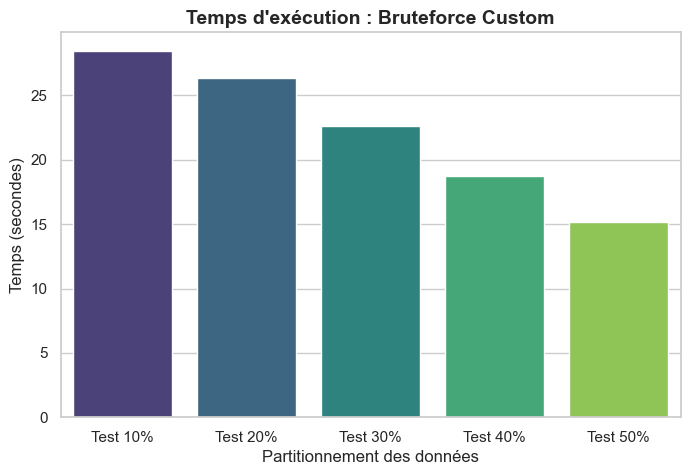

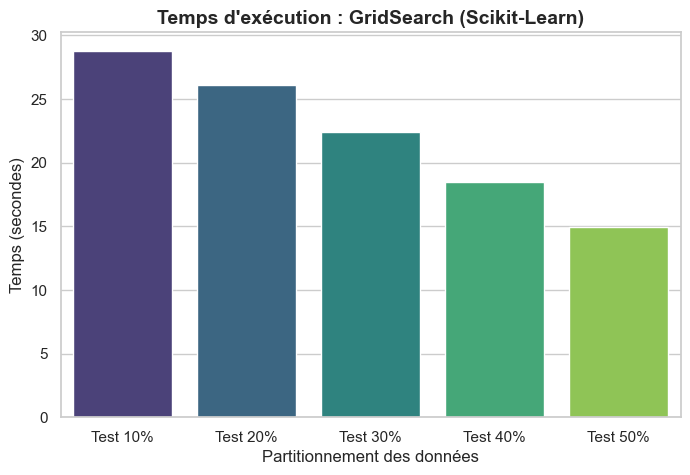

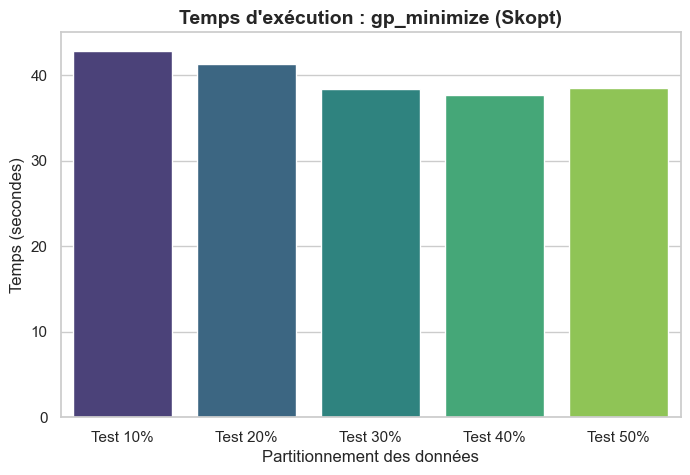

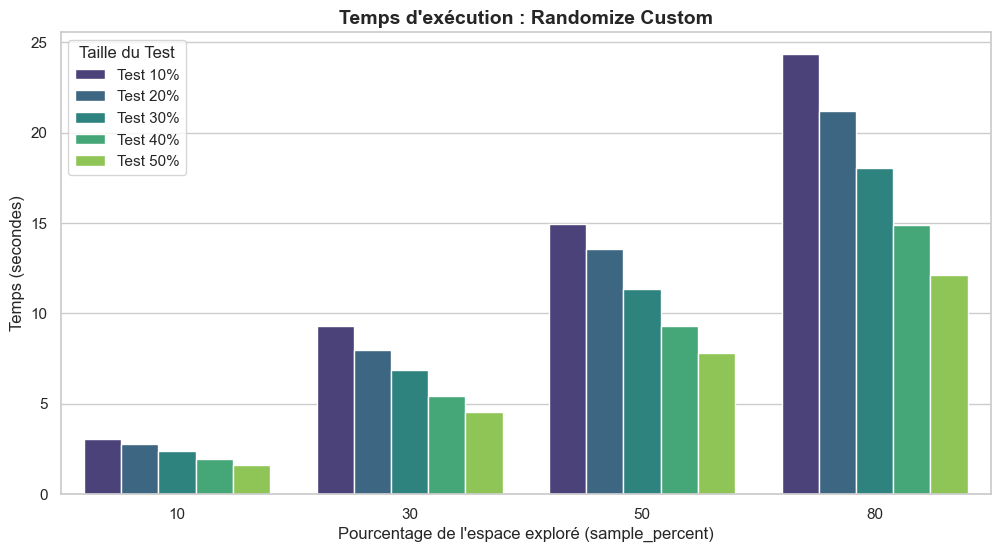

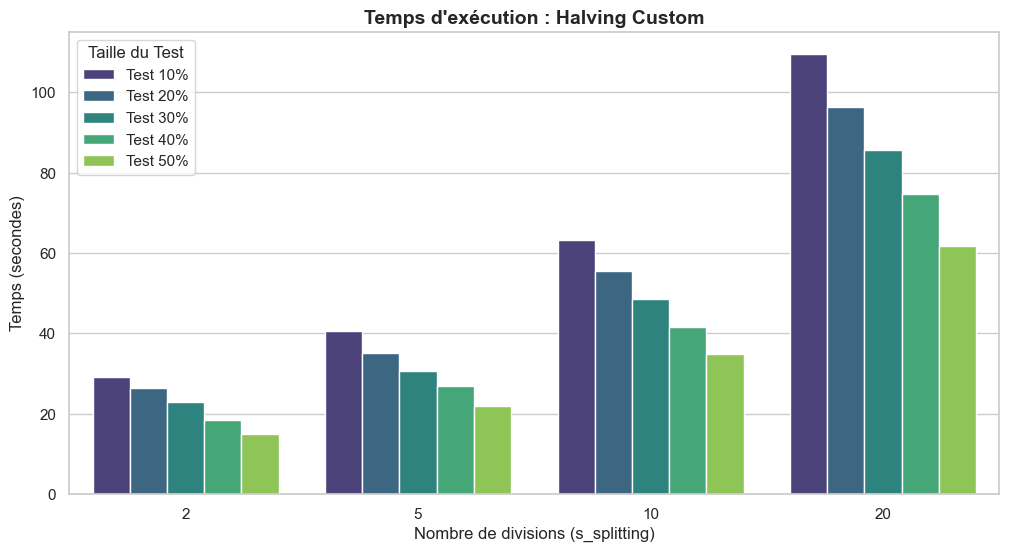

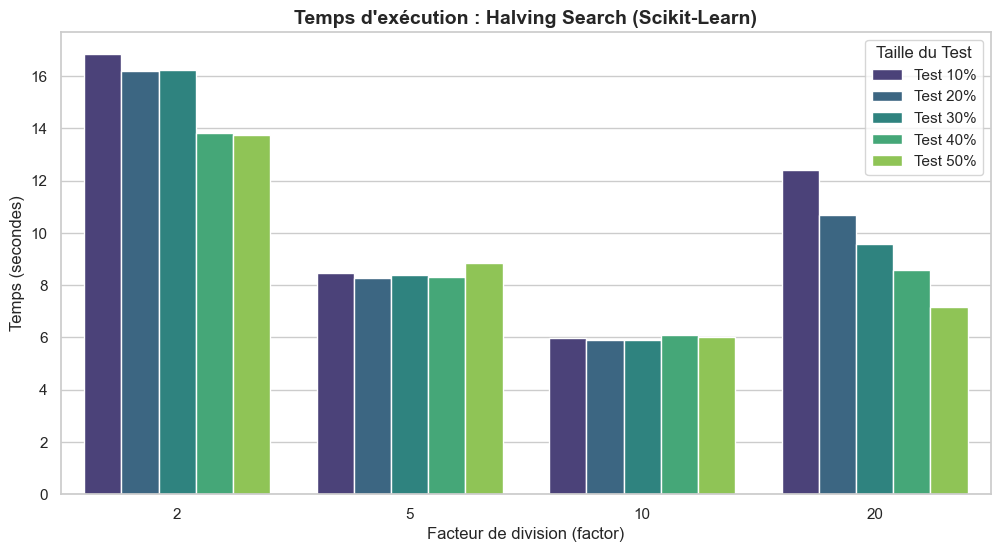

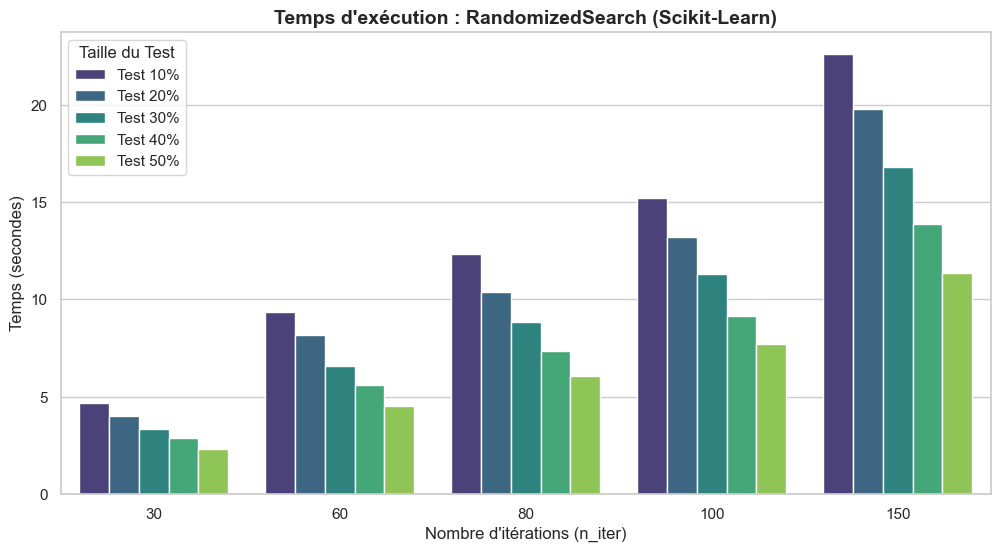

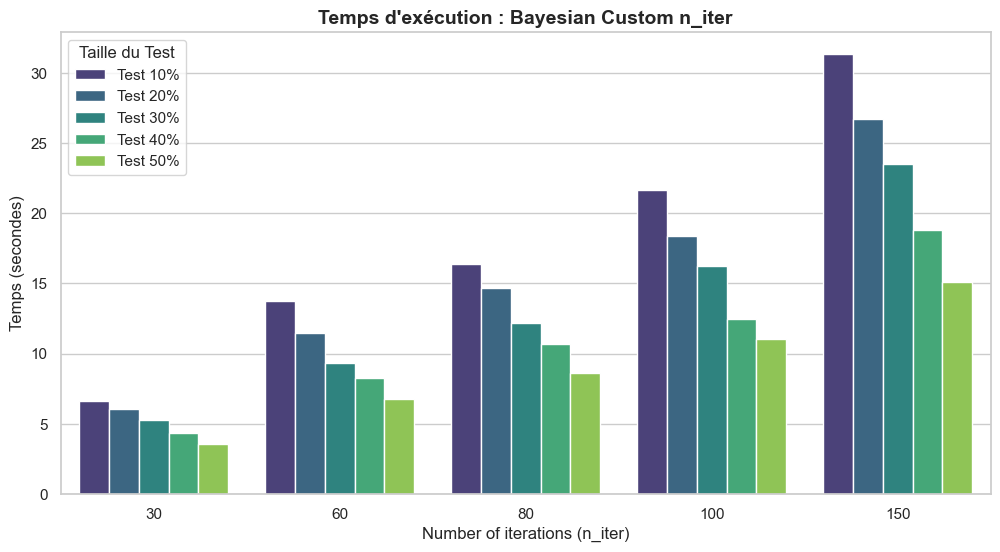

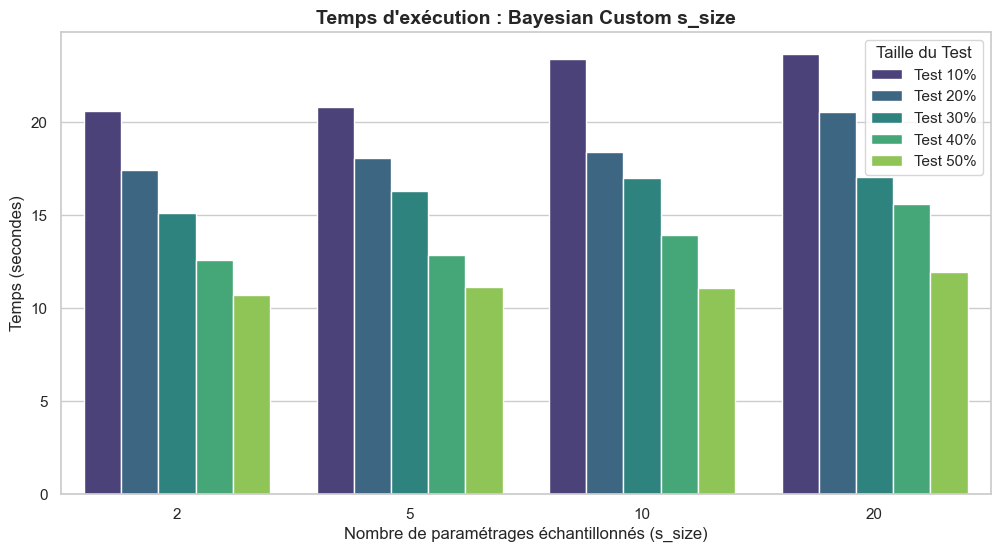

In [61]:
splits_labels = ['Test 10%', 'Test 20%', 'Test 30%', 'Test 40%', 'Test 50%']
sns.set_theme(style="whitegrid")

# Bruteforce Custom
plt.figure(figsize=(8, 5))
sns.barplot(x=splits_labels, y=time_bruteforce_list, hue=splits_labels, palette="viridis", legend=False)
plt.title("Temps d'exécution : Bruteforce Custom", fontsize=14, fontweight='bold')
plt.ylabel("Temps (secondes)")
plt.xlabel("Partitionnement des données")
plt.show()

# GridSearch Sklearn
plt.figure(figsize=(8, 5))
sns.barplot(x=splits_labels, y=time_grid_list, hue=splits_labels, palette="viridis", legend=False)
plt.title("Temps d'exécution : GridSearch (Scikit-Learn)", fontsize=14, fontweight='bold')
plt.ylabel("Temps (secondes)")
plt.xlabel("Partitionnement des données")
plt.show()

# Bayesian Skopt (gp_minimize)
plt.figure(figsize=(8, 5))
sns.barplot(x=splits_labels, y=time_gp_list, hue=splits_labels, palette="viridis", legend=False)
plt.title("Temps d'exécution : gp_minimize (Skopt)", fontsize=14, fontweight='bold')
plt.ylabel("Temps (secondes)")
plt.xlabel("Partitionnement des données")
plt.show()

# Randomize Custom
data_rand = []
idx = 0
for split in splits_labels:
    for sp in sample_percent_list:
        data_rand.append({'Split': split, 'Sample %': sp, 'Temps': time_randomized_list[idx]})
        idx += 1
df_rand = pd.DataFrame(data_rand)

plt.figure(figsize=(12, 6))
sns.barplot(data=df_rand, x='Sample %', y='Temps', hue='Split', palette="viridis")
plt.title("Temps d'exécution : Randomize Custom", fontsize=14, fontweight='bold')
plt.ylabel("Temps (secondes)")
plt.xlabel("Pourcentage de l'espace exploré (sample_percent)")
plt.legend(title="Taille du Test")
plt.show()

# Halving Custom
data_halving_c = []
idx = 0
for split in splits_labels:
    for s_split in s_splitting_list:
        data_halving_c.append({'Split': split, 's_splitting': s_split, 'Temps': time_halving_list[idx]})
        idx += 1
df_halving_c = pd.DataFrame(data_halving_c)

plt.figure(figsize=(12, 6))
sns.barplot(data=df_halving_c, x='s_splitting', y='Temps', hue='Split', palette="viridis")
plt.title("Temps d'exécution : Halving Custom", fontsize=14, fontweight='bold')
plt.ylabel("Temps (secondes)")
plt.xlabel("Nombre de divisions (s_splitting)")
plt.legend(title="Taille du Test")
plt.show()

# Halving Sklearn
data_halving_s = []
idx = 0
for split in splits_labels:
    for factor in factor_list:
        data_halving_s.append({'Split': split, 'Factor': factor, 'Temps': time_halvingS_list[idx]})
        idx += 1
df_halving_s = pd.DataFrame(data_halving_s)

plt.figure(figsize=(12, 6))
sns.barplot(data=df_halving_s, x='Factor', y='Temps', hue='Split', palette="viridis")
plt.title("Temps d'exécution : Halving Search (Scikit-Learn)", fontsize=14, fontweight='bold')
plt.ylabel("Temps (secondes)")
plt.xlabel("Facteur de division (factor)")
plt.legend(title="Taille du Test")
plt.show()

# Randomized Search Sklearn
data_rand_s = []
idx = 0
for split in splits_labels:
    for n_iter in n_iter_list:
        data_rand_s.append({'Split': split, 'n_iter': n_iter, 'Temps': time_randomizedS_list[idx]})
        idx += 1
df_rand_s = pd.DataFrame(data_rand_s)

plt.figure(figsize=(12, 6))
sns.barplot(data=df_rand_s, x='n_iter', y='Temps', hue='Split', palette="viridis")
plt.title("Temps d'exécution : RandomizedSearch (Scikit-Learn)", fontsize=14, fontweight='bold')
plt.ylabel("Temps (secondes)")
plt.xlabel("Nombre d'itérations (n_iter)")
plt.legend(title="Taille du Test")
plt.show()

# Bayesian Custom s_size
data_bayes = []
idx = 0
for split in splits_labels:
    for n_iter in n_iter_list:
        data_bayes.append({'Split': split, 'Number of iterations (n_iter)': n_iter, 'Temps': time_bayesian_list_n_iter[idx]})
        idx += 1
df_bayes_n_iter = pd.DataFrame(data_bayes)

plt.figure(figsize=(12, 6))
sns.barplot(data=df_bayes_n_iter, x='Number of iterations (n_iter)', y='Temps', hue='Split', palette="viridis")
plt.title("Temps d'exécution : Bayesian Custom n_iter", fontsize=14, fontweight='bold')
plt.ylabel("Temps (secondes)")
plt.xlabel("Number of iterations (n_iter)")
plt.legend(title="Taille du Test")
plt.show()

# Bayesian Custom s_size
data_bayes = []
idx = 0
for split in splits_labels:
    for s_size in s_size_list:
        data_bayes.append({'Split': split, 'Sample Size (s_size)': s_size, 'Temps': time_bayesian_list_s_size[idx]})
        idx += 1
df_bayes_s_size = pd.DataFrame(data_bayes)

plt.figure(figsize=(12, 6))
sns.barplot(data=df_bayes_s_size, x='Sample Size (s_size)', y='Temps', hue='Split', palette="viridis")
plt.title("Temps d'exécution : Bayesian Custom s_size", fontsize=14, fontweight='bold')
plt.ylabel("Temps (secondes)")
plt.xlabel("Nombre de paramétrages échantillonnés (s_size)")
plt.legend(title="Taille du Test")
plt.show()

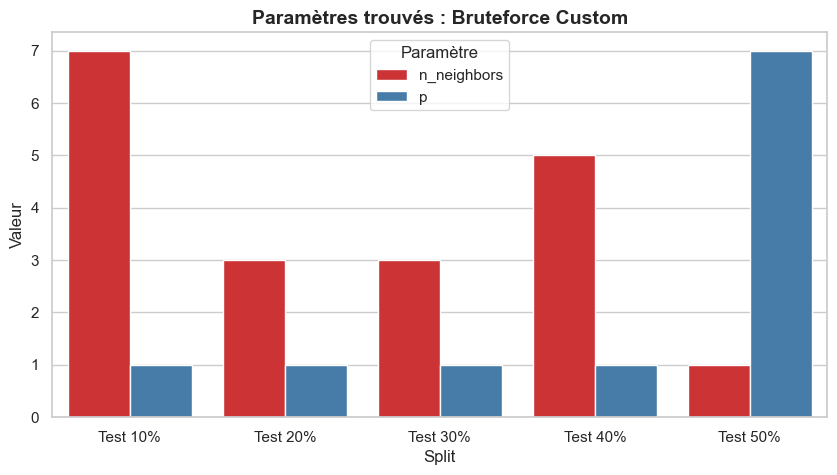

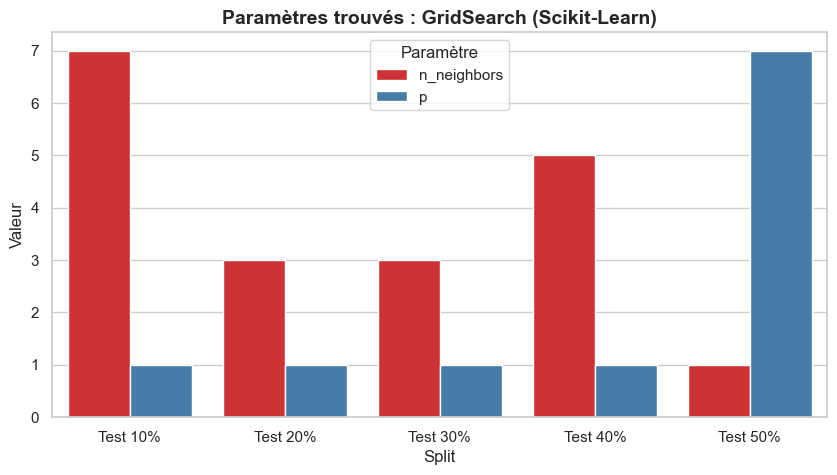

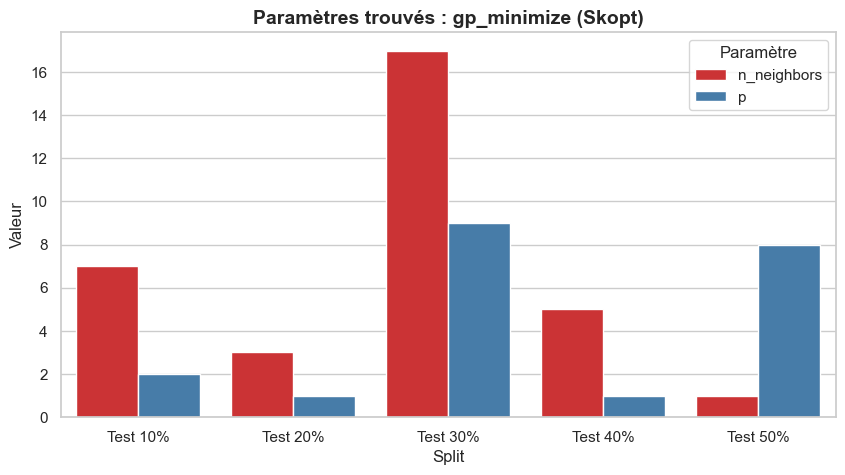

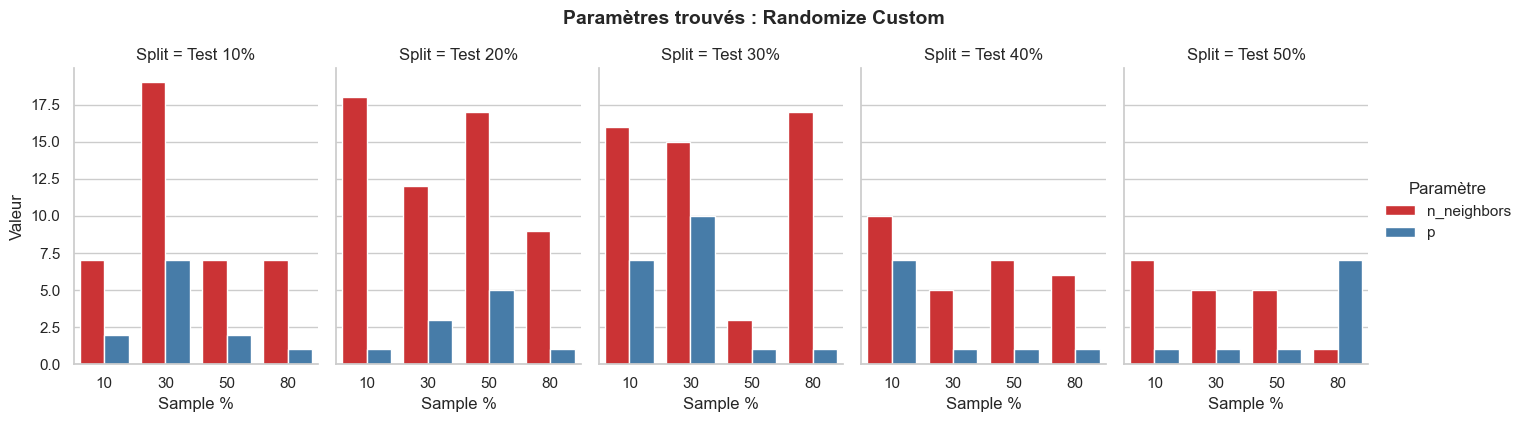

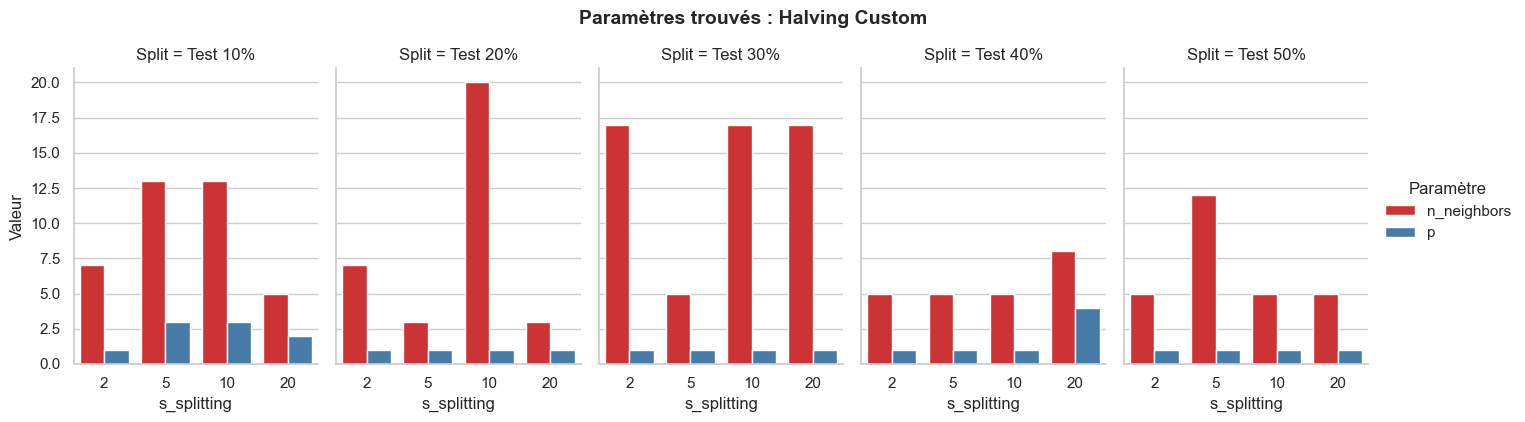

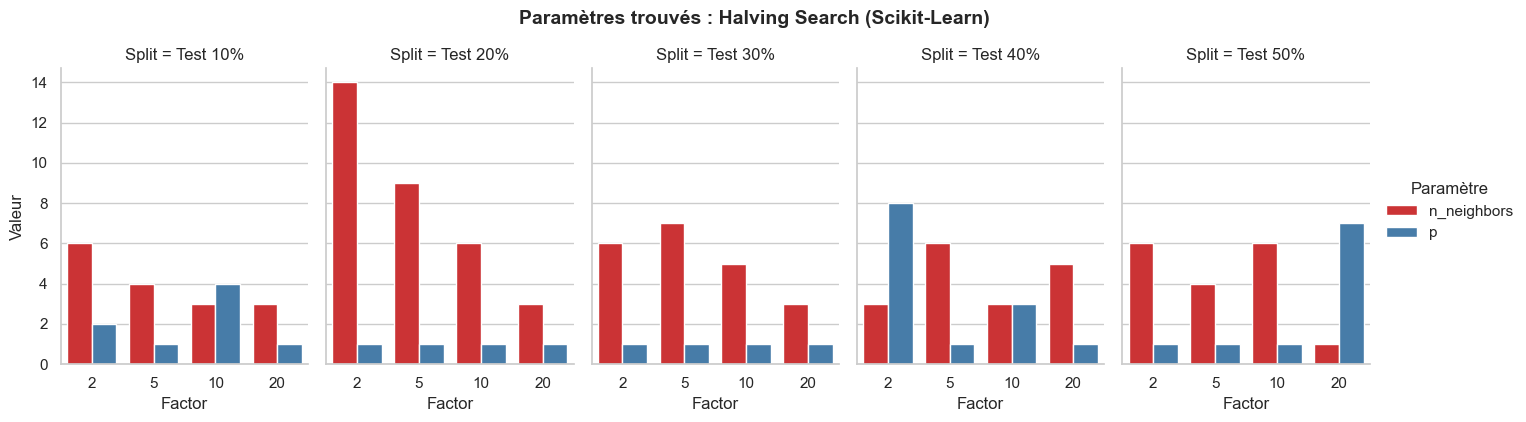

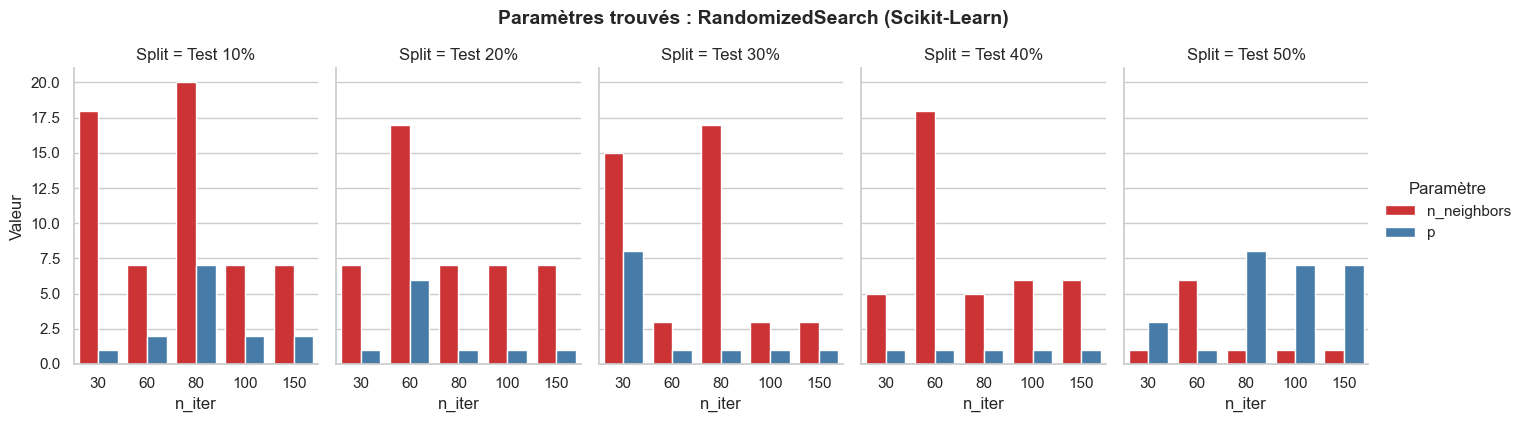

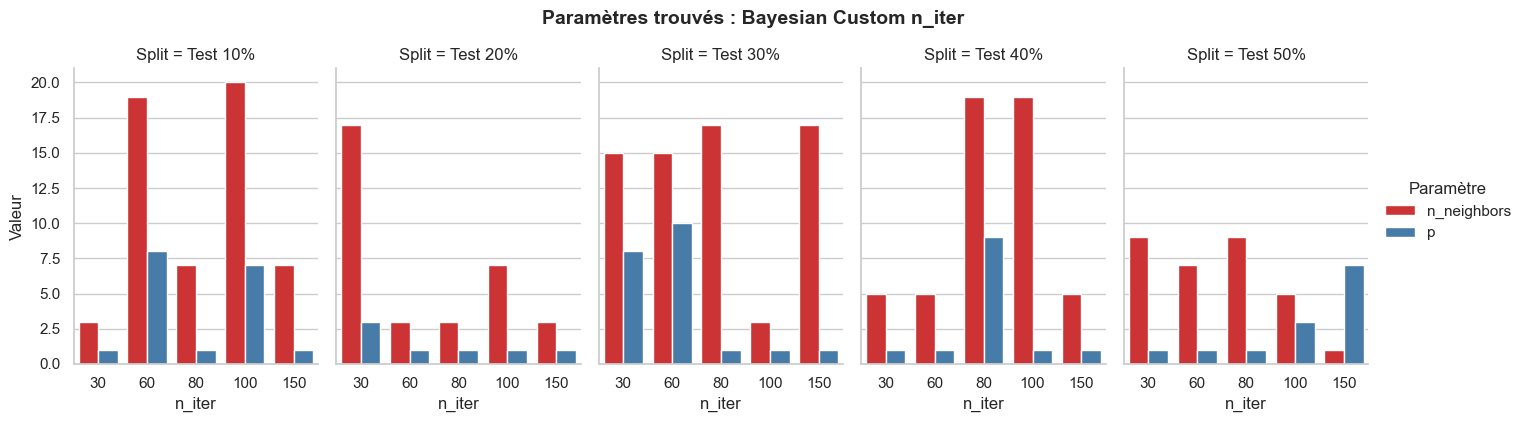

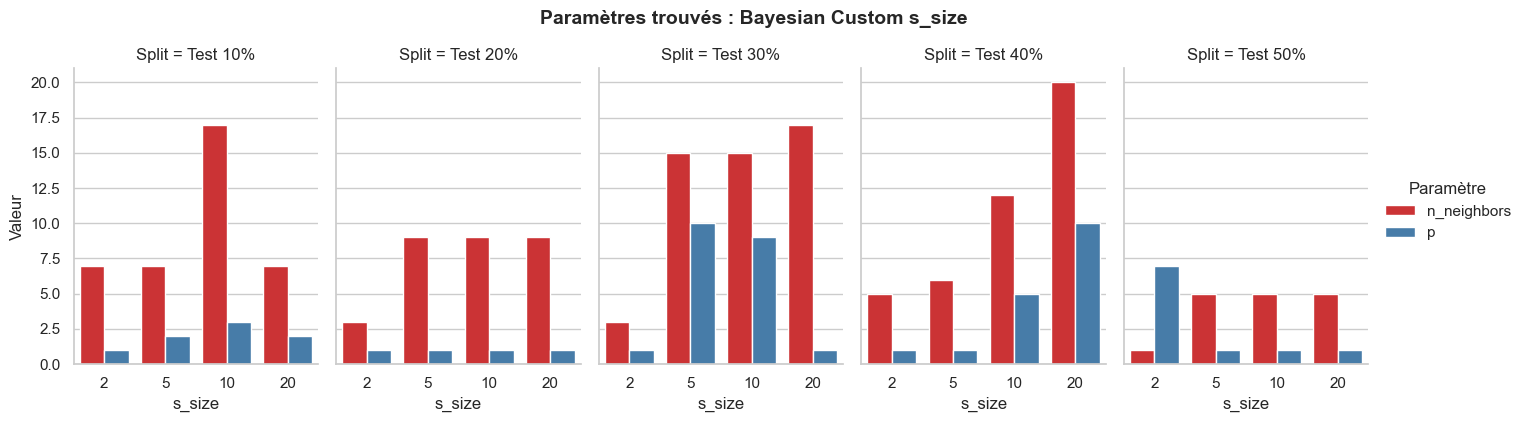

In [55]:
def preparer_donnees_globales(liste_params):
    """Fonction pour transformer les listes simples en DataFrame propre"""
    data = []
    for i, split in enumerate(splits_labels):
        params = liste_params[i]
        data.append({'Split': split, 'Paramètre': 'n_neighbors', 'Valeur': params['n_neighbors']})
        data.append({'Split': split, 'Paramètre': 'p', 'Valeur': params['p']})
    return pd.DataFrame(data)

# Bruteforce Custom
df_bf = preparer_donnees_globales(best_params_bruteforce_list)
plt.figure(figsize=(10, 5))
sns.barplot(data=df_bf, x='Split', y='Valeur', hue='Paramètre', palette='Set1')
plt.title("Paramètres trouvés : Bruteforce Custom", fontsize=14, fontweight='bold')
plt.show()

# GridSearch Sklearn
df_grid = preparer_donnees_globales(best_params_grid_list)
plt.figure(figsize=(10, 5))
sns.barplot(data=df_grid, x='Split', y='Valeur', hue='Paramètre', palette='Set1')
plt.title("Paramètres trouvés : GridSearch (Scikit-Learn)", fontsize=14, fontweight='bold')
plt.show()

# Bayesian Skopt (gp_minimize)
df_gp = preparer_donnees_globales(best_params_gp_list)
plt.figure(figsize=(10, 5))
sns.barplot(data=df_gp, x='Split', y='Valeur', hue='Paramètre', palette='Set1')
plt.title("Paramètres trouvés : gp_minimize (Skopt)", fontsize=14, fontweight='bold')
plt.show()

# Randomize Custom
data_rand = []
idx = 0
for split in splits_labels:
    for sp in sample_percent_list:
        p_dict = best_params_randomized_list[idx][0] 
        data_rand.append({'Split': split, 'Sample %': sp, 'Paramètre': 'n_neighbors', 'Valeur': p_dict['n_neighbors']})
        data_rand.append({'Split': split, 'Sample %': sp, 'Paramètre': 'p', 'Valeur': p_dict['p']})
        idx += 1
df_rand = pd.DataFrame(data_rand)

g = sns.catplot(data=df_rand, x='Sample %', y='Valeur', hue='Paramètre', col='Split', kind='bar', palette='Set1', height=4, aspect=0.7)
g.fig.suptitle("Paramètres trouvés : Randomize Custom", y=1.05, fontsize=14, fontweight='bold')
plt.show()

# Halving Custom
data_halving_c = []
idx = 0
for split in splits_labels:
    for s_split in s_splitting_list:
        p_dict = best_params_halving_list[idx][0]
        data_halving_c.append({'Split': split, 's_splitting': s_split, 'Paramètre': 'n_neighbors', 'Valeur': p_dict['n_neighbors']})
        data_halving_c.append({'Split': split, 's_splitting': s_split, 'Paramètre': 'p', 'Valeur': p_dict['p']})
        idx += 1
df_halving_c = pd.DataFrame(data_halving_c)

g = sns.catplot(data=df_halving_c, x='s_splitting', y='Valeur', hue='Paramètre', col='Split', kind='bar', palette='Set1', height=4, aspect=0.7)
g.fig.suptitle("Paramètres trouvés : Halving Custom", y=1.05, fontsize=14, fontweight='bold')
plt.show()

# Halving Sklearn
data_halving_s = []
idx = 0
for split in splits_labels:
    for factor in factor_list:
        p_dict = best_params_halvingS_list[idx][0]
        data_halving_s.append({'Split': split, 'Factor': factor, 'Paramètre': 'n_neighbors', 'Valeur': p_dict['n_neighbors']})
        data_halving_s.append({'Split': split, 'Factor': factor, 'Paramètre': 'p', 'Valeur': p_dict['p']})
        idx += 1
df_halving_s = pd.DataFrame(data_halving_s)

g = sns.catplot(data=df_halving_s, x='Factor', y='Valeur', hue='Paramètre', col='Split', kind='bar', palette='Set1', height=4, aspect=0.7)
g.fig.suptitle("Paramètres trouvés : Halving Search (Scikit-Learn)", y=1.05, fontsize=14, fontweight='bold')
plt.show()

# Randomized Search Sklearn
data_rand_s = []
idx = 0
for split in splits_labels:
    for n_iter in n_iter_list:
        p_dict = best_params_randomizedS_list[idx][0]
        data_rand_s.append({'Split': split, 'n_iter': n_iter, 'Paramètre': 'n_neighbors', 'Valeur': p_dict['n_neighbors']})
        data_rand_s.append({'Split': split, 'n_iter': n_iter, 'Paramètre': 'p', 'Valeur': p_dict['p']})
        idx += 1
df_rand_s = pd.DataFrame(data_rand_s)

g = sns.catplot(data=df_rand_s, x='n_iter', y='Valeur', hue='Paramètre', col='Split', kind='bar', palette='Set1', height=4, aspect=0.7)
g.fig.suptitle("Paramètres trouvés : RandomizedSearch (Scikit-Learn)", y=1.05, fontsize=14, fontweight='bold')
plt.show()

# Bayesian Custom n_iter
data_bayes = []
idx = 0
for split in splits_labels:
    for n_iter in n_iter_list:
        p_dict = best_params_bayesian_list_n_iter[idx][0]
        data_bayes.append({'Split': split, 'n_iter': n_iter, 'Paramètre': 'n_neighbors', 'Valeur': p_dict['n_neighbors']})
        data_bayes.append({'Split': split, 'n_iter': n_iter, 'Paramètre': 'p', 'Valeur': p_dict['p']})
        idx += 1
df_bayes_n_iter = pd.DataFrame(data_bayes)

g = sns.catplot(data=df_bayes_n_iter, x='n_iter', y='Valeur', hue='Paramètre', col='Split', kind='bar', palette='Set1', height=4, aspect=0.7)
g.fig.suptitle("Paramètres trouvés : Bayesian Custom n_iter", y=1.05, fontsize=14, fontweight='bold')
plt.show()

# Bayesian Custom s_size
data_bayes = []
idx = 0
for split in splits_labels:
    for s_size in s_size_list:
        p_dict = best_params_bayesian_list_s_size[idx][0]
        data_bayes.append({'Split': split, 's_size': s_size, 'Paramètre': 'n_neighbors', 'Valeur': p_dict['n_neighbors']})
        data_bayes.append({'Split': split, 's_size': s_size, 'Paramètre': 'p', 'Valeur': p_dict['p']})
        idx += 1
df_bayes_s_size = pd.DataFrame(data_bayes)

g = sns.catplot(data=df_bayes_s_size, x='s_size', y='Valeur', hue='Paramètre', col='Split', kind='bar', palette='Set1', height=4, aspect=0.7)
g.fig.suptitle("Paramètres trouvés : Bayesian Custom s_size", y=1.05, fontsize=14, fontweight='bold')
plt.show()

In [57]:
lignes_tableau = []
splits_labels = ['Test 10%', 'Test 20%', 'Test 30%', 'Test 40%', 'Test 50%']

# Bruteforce Custom
for i, split in enumerate(splits_labels):
    lignes_tableau.append({'Algorithme': '1. Bruteforce Custom', 'Split': split, 'Config': 'N/A', 
                           'Temps (s)': round(time_bruteforce_list[i], 2), 
                           'k (n_neighbors)': best_params_bruteforce_list[i]['n_neighbors'], 
                           'p': best_params_bruteforce_list[i]['p']})

# GridSearch Sklearn
for i, split in enumerate(splits_labels):
    lignes_tableau.append({'Algorithme': '2. GridSearch (Sklearn)', 'Split': split, 'Config': 'N/A', 
                           'Temps (s)': round(time_grid_list[i], 2), 
                           'k (n_neighbors)': best_params_grid_list[i]['n_neighbors'], 
                           'p': best_params_grid_list[i]['p']})

# Bayesian Skopt (gp_minimize)
for i, split in enumerate(splits_labels):
    lignes_tableau.append({'Algorithme': '3. gp_minimize (Skopt)', 'Split': split, 'Config': 'n_calls=60', 
                           'Temps (s)': round(time_gp_list[i], 2), 
                           'k (n_neighbors)': best_params_gp_list[i]['n_neighbors'], 
                           'p': best_params_gp_list[i]['p']})

# Randomize Custom
idx = 0
for split in splits_labels:
    for sp in sample_percent_list:
        p_dict = best_params_randomized_list[idx][0]
        lignes_tableau.append({'Algorithme': '4. Randomize Custom', 'Split': split, 'Config': f'sample% = {sp}', 
                               'Temps (s)': round(time_randomized_list[idx], 2), 
                               'k (n_neighbors)': p_dict['n_neighbors'], 
                               'p': p_dict['p']})
        idx += 1

# Halving Custom
idx = 0
for split in splits_labels:
    for s_split in s_splitting_list:
        p_dict = best_params_halving_list[idx][0]
        lignes_tableau.append({'Algorithme': '5. Halving Custom', 'Split': split, 'Config': f's_split = {s_split}', 
                               'Temps (s)': round(time_halving_list[idx], 2), 
                               'k (n_neighbors)': p_dict['n_neighbors'], 
                               'p': p_dict['p']})
        idx += 1

# Halving Sklearn
idx = 0
for split in splits_labels:
    for factor in factor_list:
        p_dict = best_params_halvingS_list[idx][0]
        lignes_tableau.append({'Algorithme': '6. Halving (Sklearn)', 'Split': split, 'Config': f'factor = {factor}', 
                               'Temps (s)': round(time_halvingS_list[idx], 2), 
                               'k (n_neighbors)': p_dict['n_neighbors'], 
                               'p': p_dict['p']})
        idx += 1

# RandomizedSearch Sklearn
idx = 0
for split in splits_labels:
    for n_iter in n_iter_list:
        p_dict = best_params_randomizedS_list[idx][0]
        lignes_tableau.append({'Algorithme': '7. RandomizedS (Sklearn)', 'Split': split, 'Config': f'n_iter = {n_iter}', 
                               'Temps (s)': round(time_randomizedS_list[idx], 2), 
                               'k (n_neighbors)': p_dict['n_neighbors'], 
                               'p': p_dict['p']})
        idx += 1

# Bayesian Custom n_iter
if len(best_params_bayesian_list_n_iter) == len(splits_labels) * len(s_size_list):
    idx = 0
    for split in splits_labels:
        for s_size in s_size_list:
            p_dict = best_params_bayesian_list_n_iter[idx][0]
            lignes_tableau.append({'Algorithme': '8. Bayesian Custom', 'Split': split, 'Config': f's_size = {s_size}', 
                                   'Temps (s)': round(time_bayesian_list_n_iter[idx], 2), 
                                   'k (n_neighbors)': p_dict['n_neighbors'], 
                                   'p': p_dict['p']})
            idx += 1

# Bayesian Custom s_size
if len(best_params_bayesian_list_s_size) == len(splits_labels) * len(s_size_list):
    idx = 0
    for split in splits_labels:
        for s_size in s_size_list:
            p_dict = best_params_bayesian_list_s_size[idx][0]
            lignes_tableau.append({'Algorithme': '8. Bayesian Custom', 'Split': split, 'Config': f's_size = {s_size}', 
                                   'Temps (s)': round(time_bayesian_list_s_size[idx], 2), 
                                   'k (n_neighbors)': p_dict['n_neighbors'], 
                                   'p': p_dict['p']})
            idx += 1

df_complet = pd.DataFrame(lignes_tableau)

print("--- TABLEAU 1.a : Résumé global pour le jeu de données standard (Test 10%) ---")
df_test_10 = df_complet[df_complet['Split'] == 'Test 10%'].copy()
display(df_test_10)

print("--- TABLEAU 1.b : Résumé global pour le jeu de données standard (Test 20%) ---")
df_test_20 = df_complet[df_complet['Split'] == 'Test 20%'].copy()
display(df_test_20)

print("--- TABLEAU 1.c : Résumé global pour le jeu de données standard (Test 30%) ---")
df_test_30 = df_complet[df_complet['Split'] == 'Test 30%'].copy()
display(df_test_30)

print("--- TABLEAU 1.d : Résumé global pour le jeu de données standard (Test 40%) ---")
df_test_40 = df_complet[df_complet['Split'] == 'Test 40%'].copy()
display(df_test_40)

print("--- TABLEAU 1.e : Résumé global pour le jeu de données standard (Test 50%) ---")
df_test_50 = df_complet[df_complet['Split'] == 'Test 50%'].copy()
display(df_test_50)

print("\n--- TABLEAU 2 : Comparaison des Temps moyens par algorithme ---")
tableau_temps = pd.pivot_table(df_complet, values='Temps (s)', index='Algorithme', columns='Split', aggfunc='mean')
display(tableau_temps.round(2))

print("\n--- TABLEAU 3 : Comparaison de la stabilité du paramètre 'k' (n_neighbors) ---")
tableau_k = pd.pivot_table(df_complet, values='k (n_neighbors)', index='Algorithme', columns='Split', aggfunc=lambda x: x.mode()[0])
display(tableau_k)

print("\n--- TABLEAU 4 : Comparaison de la stabilité du paramètre 'p' ---")
tableau_p = pd.pivot_table(df_complet, values='p', index='Algorithme', columns='Split', aggfunc=lambda x: x.mode()[0])
display(tableau_p)

--- TABLEAU 1.a : Résumé global pour le jeu de données standard (Test 10%) ---


,Algorithme,Split,Config,Temps (s),k (n_neighbors),p
0,1. Bruteforce Custom,Test 10%,N/A,28.48,7,1
5,2. GridSearch (Sklearn),Test 10%,N/A,28.81,7,1
10,3. gp_minimize (Skopt),Test 10%,n_calls=60,42.87,7,2
15,4. Randomize Custom,Test 10%,sample% = 10,3.07,7,2
16,4. Randomize Custom,Test 10%,sample% = 30,9.29,19,7
17,4. Randomize Custom,Test 10%,sample% = 50,14.95,7,2
18,4. Randomize Custom,Test 10%,sample% = 80,24.35,7,1
35,5. Halving Custom,Test 10%,s_split = 2,29.18,7,1
36,5. Halving Custom,Test 10%,s_split = 5,40.64,13,3
37,5. Halving Custom,Test 10%,s_split = 10,63.13,13,3


--- TABLEAU 1.b : Résumé global pour le jeu de données standard (Test 20%) ---


,Algorithme,Split,Config,Temps (s),k (n_neighbors),p
1,1. Bruteforce Custom,Test 20%,N/A,26.36,3,1
6,2. GridSearch (Sklearn),Test 20%,N/A,26.12,3,1
11,3. gp_minimize (Skopt),Test 20%,n_calls=60,41.31,3,1
19,4. Randomize Custom,Test 20%,sample% = 10,2.75,18,1
20,4. Randomize Custom,Test 20%,sample% = 30,7.97,12,3
21,4. Randomize Custom,Test 20%,sample% = 50,13.56,17,5
22,4. Randomize Custom,Test 20%,sample% = 80,21.21,9,1
39,5. Halving Custom,Test 20%,s_split = 2,26.40,7,1
40,5. Halving Custom,Test 20%,s_split = 5,35.12,3,1
41,5. Halving Custom,Test 20%,s_split = 10,55.61,20,1


--- TABLEAU 1.c : Résumé global pour le jeu de données standard (Test 30%) ---


...

Split,Test 10%,Test 20%,Test 30%,Test 40%,Test 50%
Algorithme,,,,,
1. Bruteforce Custom,28.48,26.36,22.61,18.76,15.17
2. GridSearch (Sklearn),28.81,26.12,22.40,18.49,14.94
3. gp_minimize (Skopt),42.87,41.31,38.41,37.73,38.49
4. Randomize Custom,12.92,11.37,9.67,7.90,6.53
5. Halving Custom,60.64,53.38,46.90,40.44,33.38
6. Halving (Sklearn),10.92,10.26,10.03,9.20,8.93
7. RandomizedS (Sklearn),12.84,11.11,9.38,7.78,6.40
8. Bayesian Custom,22.09,18.60,16.34,13.73,11.20



--- TABLEAU 3 : Comparaison de la stabilité du paramètre 'k' (n_neighbors) ---


Split,Test 10%,Test 20%,Test 30%,Test 40%,Test 50%
Algorithme,,,,,
1. Bruteforce Custom,7,3,3,5,1
2. GridSearch (Sklearn),7,3,3,5,1
3. gp_minimize (Skopt),7,3,17,5,1
4. Randomize Custom,7,9,3,5,5
5. Halving Custom,13,3,17,5,5
6. Halving (Sklearn),3,3,3,3,6
7. RandomizedS (Sklearn),7,7,3,5,1
8. Bayesian Custom,7,9,15,5,5



--- TABLEAU 4 : Comparaison de la stabilité du paramètre 'p' ---


Split,Test 10%,Test 20%,Test 30%,Test 40%,Test 50%
Algorithme,,,,,
1. Bruteforce Custom,1,1,1,1,7
2. GridSearch (Sklearn),1,1,1,1,7
3. gp_minimize (Skopt),2,1,9,1,8
4. Randomize Custom,2,1,1,1,1
5. Halving Custom,3,1,1,1,1
6. Halving (Sklearn),1,1,1,1,1
7. RandomizedS (Sklearn),2,1,1,1,7
8. Bayesian Custom,2,1,1,1,1


L'analyse des résultats obtenus (temps d'exécution et paramètres optimaux trouvés) en faisant varier le partitionnement des données et les paramètres des fonctions de réglage permet d'avoir une idée sur l'efficacité des algorithmes testés.

En regardant les performances temporelles dans le Tableau 2, on remarque une tendance qui revient, le temps d'exécution diminue à mesure que la taille du jeu de données de test augmente, ça s'explique par le fait que le nombre de données d'entrainement diminue et donc que c'est l'entrainement la partie la plus chronophage. Les méthodes exhaustives, comme notre fonction Bruteforce ou le GridSearchCV de scikit-learn, affichent des temps de calcul élevés et quasi identiques, il fallait s'y attendre car elles sont réputées lentes de plus on peut donc valider la pertinence de notre implémentation (dans la question précédente on a vu qu'on obtenait les mêmes resultats entre les deux, et maintenant on voit qu'elles ont le même temps d'exécution). À l'inverse, les approches stochastiques comme le Randomized Search parviennent à réduire ce temps de plus de 50 % en n'explorant qu'une fraction de l'espace de recherche. Il est aussi intéressant de remarquer que l'optimisation bayésienne a un coût fixe important dû à la nécessité de souvent ré-estimer le modèle de régression par processus gaussien pour prédire les scores (chronophage).

Concernant la capacité à trouver les meilleurs hyperparamètres, les Tableaux 3 et 4 montrent que pour la majorité des partitionnements (de 10 % à 40 % de test), l'optimum global gravite autour de k=7 et p=1. Par contre on peut remarquer un phénomène de surapprentissage (overfitting) lors de l'utilisation d'un split à 50 % de test. Avec ce partitionnement, le manque de données d'entraînement pousse les algorithmes, y compris le Bruteforce, à choisir un voisinage très réduit (k=1), et cela nuit à la capacité de généralisation du modèle. Les méthodes comme le Randomized Search ou l'optimisation bayésienne réussissent à mieux identifier l'optimum ou des valeurs très proches, prouvant qu'ils peuvent être meilleurs par rapport à une recherche complète, à condition qu'il y ait assez d'itérations.

Donc pour une grille de paramètres de taille modérée, le Randomized Search offre le meilleur équilibre entre rapidité et fidélité aux résultats optimaux. Bien que des techniques comme le Halving Search soient extrêmement rapides, elles ont un risque d'élimination prématurée des bons candidats (voir 2.c) si le facteur de division est trop agressif. Finalement, pour ce jeu de données spécifique, la distance Manhattan (p=1) semble être la mesure de proximité la plus robuste pour assurer une classification performante des observations.